In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)

Load XGBoost engineered dataset

In [3]:
df = pd.read_parquet("../../data/processed/engineered_features_xgboost.parquet")
df.shape

(2294985, 46)

In [4]:
meta_cols = ['stub_id', 'particle_id', 'label', 'target', 'final_class']
feature_cols = [c for c in df.columns if c not in meta_cols]

print(f"# of Features: {len(feature_cols)}")

# of Features: 41


### Group aware train/test/val split 

Two-stage GroupShuffleSplit:
1. Split off 20% test (by stub_id)
2. From the remaining 80%, split off 25% as val (= 20% of total)

Result: ~60% train, ~20% val, ~20% test. No stub overlap between any pair.

In [5]:
X = df[feature_cols].values.astype(np.float32)
y = df['target'].values.astype(np.float32)
groups = df['stub_id'].values

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
trainval_idx, test_idx = next(gss1.split(X, y, groups))

X_trainval, X_test = X[trainval_idx], X[test_idx]
y_trainval, y_test = y[trainval_idx], y[test_idx]
groups_trainval = groups[trainval_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)  # 25% of 80% = 20% of total
train_idx_rel, val_idx_rel = next(gss2.split(X_trainval, y_trainval, groups_trainval))

X_train = X_trainval[train_idx_rel]
X_val = X_trainval[val_idx_rel]
y_train = y_trainval[train_idx_rel]
y_val = y_trainval[val_idx_rel]

groups_train = set(groups_trainval[train_idx_rel])
groups_val = set(groups_trainval[val_idx_rel])
groups_test = set(groups[test_idx])

In [6]:
# Verify no stub leakage
assert len(groups_train & groups_val) == 0, 'Train-Val stub leak!'
assert len(groups_train & groups_test) == 0, 'Train-Test stub leak!'
assert len(groups_val & groups_test) == 0, 'Val-Test stub leak!'

print("No stub-level leakage")

No stub-level leakage


Summarize the train/val/test split

In [7]:
total_obs = len(y_train) + len(y_val) + len(y_test)

summary = pd.DataFrame({
    "Split":         ["Train",          "Val",          "Test"],
    "Observations":  [len(y_train),     len(y_val),     len(y_test)],
    "% of Total":    [len(y_train)/total_obs*100, len(y_val)/total_obs*100, len(y_test)/total_obs*100],
    "GSR (target=1)":[int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    "GSR %":         [y_train.mean()*100, y_val.mean()*100, y_test.mean()*100],
    "Unique Stubs":  [len(groups_train), len(groups_val), len(groups_test)],
})

summary["% of Total"] = summary["% of Total"].map("{:.1f}%".format)
summary["GSR %"]      = summary["GSR %"].map("{:.2f}%".format)

print(f"Total observations : {total_obs:,}")
print(f"Total features     : {X_train.shape[1]}")
print(f"Total unique stubs : {len(groups_train | groups_val | groups_test):,}\n")
print(summary.to_string(index=False))
print(f"\n\nNOTE: Do not use these summary statistics due to # of features changing for Baseline v2")

Total observations : 2,294,985
Total features     : 41
Total unique stubs : 3,786

Split  Observations % of Total  GSR (target=1)  GSR %  Unique Stubs
Train       1444147      62.9%          717835 49.71%          2271
  Val        407614      17.8%          151162 37.08%           757
 Test        443224      19.3%          209949 47.37%           758


NOTE: Do not use these summary statistics due to # of features changing for Baseline v2


## Baseline v1
Default threshold = 0.5

__Train:__

In [12]:
baseline_diag = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.1,
    min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
    subsample=0.8, colsample_bytree=0.8,
    tree_method='hist', eval_metric='aucpr',
    early_stopping_rounds=30, random_state=42, n_jobs=-1,
)

# eval on both train and val to get learning curves
baseline_diag.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50
)

[0]	validation_0-aucpr:0.99970	validation_1-aucpr:0.99974
[50]	validation_0-aucpr:0.99998	validation_1-aucpr:0.99997
[100]	validation_0-aucpr:1.00000	validation_1-aucpr:0.99999
[150]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[200]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[250]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[284]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

__Eval the baseline's train & val curves__

In [13]:
results = baseline_diag.evals_result()
train_aucpr = results['validation_0']['aucpr']
val_aucpr = results['validation_1']['aucpr']

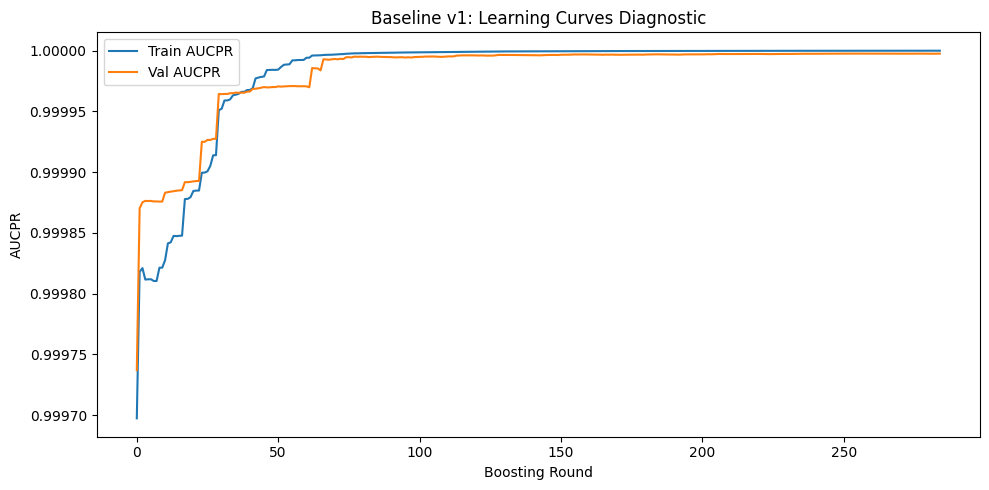

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(train_aucpr, label='Train AUCPR')
ax.plot(val_aucpr, label='Val AUCPR')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('AUCPR')
ax.set_title('Baseline v1: Learning Curves Diagnostic')
ax.legend()
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()

__Concern to Investigate__

The AUC PR jumps to 0.999 immediately.

Suspected leakage.

__Check feature importance__

In [15]:
importances = baseline_diag.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
print(f"Baseline v1: Top 5 Important Features\n\n{feat_imp.head(5)}")

Baseline v1: Top 5 Important Features

core_gsr_count            0.978378
log_pb_plus_sb            0.013775
pb_sb_over_non_ba_mass    0.004030
sb                        0.000520
pb_ba_over_non_sb_mass    0.000399
dtype: float32


### Evaluate against test

In [16]:
df_test_class_label = df.iloc[test_idx][['final_class', 'label']]

y_prob_test = baseline_diag.predict_proba(X_test)[:, 1]
y_pred_test = baseline_diag.predict(X_test)

cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"FPR: {fp/(fp+tn):.6f}")

fp_mask = (y_pred_test == 1) & (y_test == 0)
fn_mask = (y_pred_test == 0) & (y_test == 1)
print("\nFP by class:")
print(df_test_class_label.loc[fp_mask, 'final_class'].value_counts())
print("\nFN by class:")
print(df_test_class_label.loc[fn_mask, 'final_class'].value_counts())

fp_probs = y_prob_test[fp_mask]
print(f"\nFP probs: min={fp_probs.min():.4f}, median={np.median(fp_probs):.4f}, max={fp_probs.max():.4f}")

TN=233,124  FP=151  FN=39  TP=209,910
FPR: 0.000647

FP by class:
final_class
BaAl      106
BaCaSi     39
TiZnGd      3
CuZn        2
Hg          1
Name: count, dtype: int64

FN by class:
final_class
BaSb    24
PbBa    15
Name: count, dtype: int64

FP probs: min=0.5012, median=0.7443, max=1.0000


### Problem with "core_gsr_count" feature --> Potential Feature Leakage

The learning curve starts at 0.9997 AUCPR on the very first boosting round and reaches 0.9999+ by round 50. The model essentially solves the problem immediately. The train and val curves track closely with no divergence, so there's no classical overfitting but that's because the task is too easy.

`core_gsr_count` accounts for 97.8% of all split importance. Suspect #1 for leakage. The model is almost entirely a single-feature decision tree that checks how many of Pb/Ba/Sb are present, with the remaining features handling a thin margin of edge cases (log_pb_plus_sb at 1.4% and everything else below 0.5%).

Feature Leakage or Label Proxy. The model learned the domain experts' rule in one split and barely needs anything else. It's not learning chemical relationships, it's learning a shortcut.